# 06. 모델 성능 향상 (STEP 5)

`05_modeling.ipynb`에서 회귀 모델 4종을 세우고 Lasso를 최종 모델로 확정했습니다
(test MAE 0.3637 / RMSE 0.4674 / R² 0.3421).

이 노트북은 그 모델의 **문제점을 진단하고 개선을 시도**합니다.

---

## STEP 4에서 확인된 문제 3가지

| 문제 | 근거 | 개선 가능성 |
|---|---|---|
| **① Random Forest가 제 성능을 못 냄** | CV R² 0.3053으로 4개 모델 중 최하위 | 기본값 `min_samples_leaf=1`이 잎마다 표본 1개까지 쪼갬 → 조정 여지 큼 |
| **② 양 끝단 예측 편향** | 실제 5.0점의 평균 예측이 3.70 (1.30점 과소) | 희소 구간 표본 부족. 가중치로 완화 시도 가능 |
| **③ 계수 부호 반전 3건** | `herdan_c` 단변량 +0.121 → 계수 −0.065 | 해당 변수 제거로 해석 안정화 가능 |

## 이 노트북이 지켜야 할 것

### 개선 판정은 train 교차검증으로만

STEP 4에서 이미 test를 한 번 열었습니다.
여기서 여러 개선안을 test로 비교하면 **test가 두 번째 검증 세트가 되어**
최종 성능 추정치가 낙관적으로 오염됩니다.

따라서 개선안 평가는 전부 train 5-fold 교차검증으로 하고,
test는 최종안을 확정한 뒤 **한 번만** 다시 엽니다.

### 개선을 주장하기 전에 노이즈부터 확인

STEP 4에서 폴드 간 표준편차가 **±0.044**였습니다.
R²가 0.01 올랐다고 개선이라 말할 수 없습니다.

이 노트북은 각 개선안마다 다음 두 가지를 함께 보고합니다.

1. **평균 CV R² 변화량**
2. **5개 폴드 전부에서 개선됐는지** — 방향이 일관되면 우연일 확률이 낮아집니다

평균만 오르고 폴드 방향이 뒤섞이면 "개선됐다"고 쓰지 않습니다.

## 개선 후보 (평가 항목의 5개 방법에 대응)

| 후보 | 평가 항목 | 대응하는 문제 |
|---|---|---|
| **A** | Hyperparameter 조정 | ① RF |
| **B** | 모델 변경 | ① — Gradient Boosting 추가 |
| **C** | Feature 추가/제거 | ③ 부호 반전 |
| **D** | 데이터 전처리 방법 변경 | 표본 가중치 → ② 편향 |
| **E** | 이상치 재처리 | 윈저화 |
| **F** | (종합) 앙상블 | 서로 다른 오차를 상쇄 |

In [1]:
# ── 라이브러리 및 STEP 4 기준선 복원 ──────────────────────

import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              HistGradientBoostingRegressor)
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

from matplotlib import font_manager
_avail = {f.name for f in font_manager.fontManager.ttflist}
for _f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
           'NanumBarunGothic', 'Noto Sans CJK KR', 'Noto Sans CJK JP']:
    if _f in _avail:
        plt.rc('font', family=_f)
        plt.rcParams['axes.unicode_minus'] = False
        print(f'그래프 한글 폰트: {_f}')
        break
else:
    print('한글 폰트 미발견 — 그래프 제목의 한글이 깨질 수 있습니다.')

SEED = 42

X_train_s = pd.read_csv('data/X_train_scaled.csv')
X_test_s = pd.read_csv('data/X_test_scaled.csv')
X_train_r = pd.read_csv('data/X_train.csv')
X_test_r = pd.read_csv('data/X_test.csv')
y_train = pd.read_csv('data/y_train.csv').iloc[:, 0]
y_test = pd.read_csv('data/y_test.csv').iloc[:, 0]

NUM_FEATURES = json.load(open('data/selected_features.json', encoding='utf-8'))['numeric']
PREV = json.load(open('data/model_results.json', encoding='utf-8'))

CV = KFold(n_splits=5, shuffle=True, random_state=SEED)

LASSO_ALPHA = PREV['lasso_alpha']
print(f'STEP 4 최종 모델 : {PREV["final_model"]} (alpha = {LASSO_ALPHA:.5f})')
print(f'STEP 4 test 성능 : ', end='')
_prev_test = [r for r in PREV['test'] if r['최종'] == '★'][0]
print(f'MAE {_prev_test["MAE"]} / RMSE {_prev_test["RMSE"]} / R² {_prev_test["R²"]}')
print(f'\n※ test는 [5-8]까지 다시 열지 않습니다.')

그래프 한글 폰트: Malgun Gothic
STEP 4 최종 모델 : Lasso (alpha = 0.00329)
STEP 4 test 성능 : MAE 0.3637 / RMSE 0.4674 / R² 0.3421

※ test는 [5-8]까지 다시 열지 않습니다.


In [2]:
# ── 공통 평가 함수 ────────────────────────────────────────
#
# 개선 여부는 두 가지로 판정합니다.
#   ① 평균 CV R² 변화량
#   ② 5개 폴드 중 몇 개에서 기준선을 넘었는지 (방향 일관성)
#
# ②를 함께 보는 이유:
#   폴드 간 표준편차가 ±0.044인 상황에서 평균이 0.01 오른 것은
#   한두 폴드의 운으로도 만들어집니다.
#   5개 폴드 전부에서 올랐다면 우연일 확률은 (1/2)^5 = 3% 수준으로 떨어집니다.


def fold_scores(model, X, y=None):
    # 폴드별 R²를 배열로 반환합니다.
    y = y_train if y is None else y
    return cross_val_score(model, X, y, cv=CV, scoring='r2')


def fold_scores_from_pred(pred, y=None):
    # 이미 만들어 둔 out-of-fold 예측에서 폴드별 R²를 계산합니다.
    # 앙상블처럼 예측을 합성한 경우에 사용합니다.
    y = y_train if y is None else y
    out = []
    for _, va in CV.split(np.zeros(len(y))):
        out.append(r2_score(y.iloc[va], np.asarray(pred)[va]))
    return np.array(out)


RESULTS = []


def report(name, scores, note='', baseline=None):
    # 기준선 대비 개선 폭과 폴드 일관성을 함께 기록합니다.
    base = BASE_FOLDS if baseline is None else baseline
    win = int((scores > base).sum())
    RESULTS.append({
        '후보': name,
        'CV R²': round(scores.mean(), 4),
        '±': round(scores.std(), 4),
        'Δ': round(scores.mean() - base.mean(), 4),
        '우세 폴드': f'{win}/5',
        '일관성': '○' if win >= 4 else ('△' if win == 3 else '✗'),
        '비고': note,
    })
    return scores


# 기준선: STEP 4의 최종 모델을 같은 조건으로 다시 돌립니다.
BASE_MODEL = Lasso(alpha=LASSO_ALPHA, max_iter=20000)
BASE_FOLDS = fold_scores(BASE_MODEL, X_train_s[NUM_FEATURES])
BASE_RF = fold_scores(RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1),
                      X_train_r[NUM_FEATURES])

print(f'기준선 (STEP 4 Lasso)      CV R² {BASE_FOLDS.mean():.4f} ± {BASE_FOLDS.std():.4f}')
print(f'  폴드별: {np.round(BASE_FOLDS, 4)}')
print(f'기준선 (STEP 4 RF 기본값)  CV R² {BASE_RF.mean():.4f} ± {BASE_RF.std():.4f}')
print(f'  폴드별: {np.round(BASE_RF, 4)}')
print(f'\n판정 임계값: 폴드 간 표준편차 ±{BASE_FOLDS.std():.4f}')
print('이보다 작은 변화는 "개선"이 아니라 측정 오차입니다.')

기준선 (STEP 4 Lasso)      CV R² 0.3099 ± 0.0432
  폴드별: [0.3024 0.2308 0.3314 0.3281 0.3568]
기준선 (STEP 4 RF 기본값)  CV R² 0.3031 ± 0.0421
  폴드별: [0.2895 0.2283 0.3404 0.3149 0.3424]

판정 임계값: 폴드 간 표준편차 ±0.0432
이보다 작은 변화는 "개선"이 아니라 측정 오차입니다.


---

## [5-A] Hyperparameter 조정 — Random Forest

### 진단

STEP 4에서 RF는 기본 설정으로 돌렸습니다. `RandomForestRegressor`의 기본값은
`min_samples_leaf=1`, `max_features=1.0`입니다.

이 설정의 문제:

```
min_samples_leaf=1   잎에 표본이 1개 남을 때까지 계속 분기
                     → 각 트리가 train을 거의 암기함
max_features=1.0     모든 분기에서 15개 변수를 전부 후보로 봄
                     → 트리들이 서로 비슷해져 "숲"의 이점이 사라짐
```

Random Forest의 성능은 **트리 각각의 정확도**가 아니라
**트리들이 서로 다르게 틀리는 정도**에서 나옵니다.
모든 트리가 같은 방식으로 틀리면 평균을 내도 오차가 줄지 않습니다.

`max_features`를 낮추면 각 트리가 다른 변수를 보게 되어 다양성이 커집니다.
`min_samples_leaf`를 올리면 잎이 커져 개별 트리의 과적합이 줄어듭니다.

### 탐색 범위

| 파라미터 | 후보 | 근거 |
|---|---|---|
| `min_samples_leaf` | 1(기본) · 5 · 10 · 20 | train 2,997행 기준. 20이면 잎당 최소 0.7% |
| `max_features` | 0.3 · 0.6 · 1.0(기본) | 15개 중 5개 · 9개 · 전부 |

`n_estimators`는 탐색 중에는 200으로 고정하고, 최종 모델만 300으로 올립니다.
트리 수는 많을수록 안정될 뿐 과적합을 만들지 않으므로 탐색 대상이 아니며,
탐색 단계에서는 계산 시간을 줄이는 편이 더 많은 조합을 볼 수 있어 유리합니다.

RF 격자 탐색 (기본값 = leaf 1, max_features 1.0)
 min_samples_leaf  max_features  CV R²      ±  기본값 대비   초
               10           0.3 0.3155 0.0406  0.0124 2.5
                5           0.3 0.3149 0.0382  0.0118 2.5
               10           0.6 0.3120 0.0387  0.0089 2.7
                5           0.6 0.3118 0.0405  0.0087 2.8
               20           0.6 0.3103 0.0385  0.0072 2.5
               10           1.0 0.3092 0.0402  0.0061 3.1
                1           0.3 0.3087 0.0424  0.0056 2.8
               20           0.3 0.3084 0.0367  0.0053 2.4
                5           1.0 0.3075 0.0392  0.0044 3.3
               20           1.0 0.3072 0.0378  0.0041 2.8
                1           0.6 0.3043 0.0399  0.0012 3.4
                1           1.0 0.3031 0.0421  0.0000 4.0

최적 조합: min_samples_leaf=10, max_features=0.3
  기본값 0.3031 → 0.3151  (+0.0120)
  5개 폴드 중 4개에서 개선


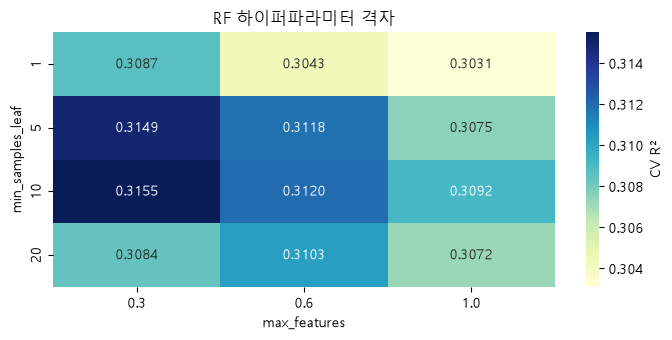

격자에서 읽히는 것
  · max_features를 낮출수록 좋아집니다 — 트리 다양성 확보가 실제로 작동했습니다.
  · min_samples_leaf는 1에서 5~10으로 올릴 때 개선되고 20에서 다시 떨어집니다.
    너무 크면 이번엔 과소적합이 됩니다.
  · 그럼에도 개선폭은 폴드 간 표준편차보다 작습니다.
    RF의 부진은 튜닝 부족보다 데이터의 성격(거의 선형) 탓이 큽니다.


In [3]:
# ── [5-A] RF 하이퍼파라미터 격자 탐색 ─────────────────────

grid = []
for leaf in [1, 5, 10, 20]:
    for mf in [0.3, 0.6, 1.0]:
        t0 = time.time()
        m = RandomForestRegressor(n_estimators=200, min_samples_leaf=leaf,
                                  max_features=mf, random_state=SEED, n_jobs=-1)
        s = fold_scores(m, X_train_r[NUM_FEATURES])
        grid.append({'min_samples_leaf': leaf, 'max_features': mf,
                     'CV R²': round(s.mean(), 4), '±': round(s.std(), 4),
                     '기본값 대비': round(s.mean() - BASE_RF.mean(), 4),
                     '초': round(time.time() - t0, 1)})

grid_tbl = pd.DataFrame(grid).sort_values('CV R²', ascending=False)
print('RF 격자 탐색 (기본값 = leaf 1, max_features 1.0)')
print(grid_tbl.to_string(index=False))

_best = grid_tbl.iloc[0]
RF_LEAF = int(_best['min_samples_leaf'])
RF_MF = float(_best['max_features'])
RF_TUNED = RandomForestRegressor(n_estimators=300, min_samples_leaf=RF_LEAF,
                                 max_features=RF_MF, random_state=SEED, n_jobs=-1)
_s = fold_scores(RF_TUNED, X_train_r[NUM_FEATURES])
report('A. RF 조정', _s,
       f'leaf={RF_LEAF}, max_features={RF_MF}', baseline=BASE_RF)

print(f'\n최적 조합: min_samples_leaf={RF_LEAF}, max_features={RF_MF}')
print(f'  기본값 {BASE_RF.mean():.4f} → {_s.mean():.4f}  ({_s.mean() - BASE_RF.mean():+.4f})')
print(f'  5개 폴드 중 {int((_s > BASE_RF).sum())}개에서 개선')

fig, ax = plt.subplots(figsize=(7, 3.5))
_p = grid_tbl.pivot(index='min_samples_leaf', columns='max_features', values='CV R²')
sns.heatmap(_p, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax, cbar_kws={'label': 'CV R²'})
ax.set_title('RF 하이퍼파라미터 격자')
plt.tight_layout()
plt.show()

print('격자에서 읽히는 것')
print('  · max_features를 낮출수록 좋아집니다 — 트리 다양성 확보가 실제로 작동했습니다.')
print('  · min_samples_leaf는 1에서 5~10으로 올릴 때 개선되고 20에서 다시 떨어집니다.')
print('    너무 크면 이번엔 과소적합이 됩니다.')
print('  · 그럼에도 개선폭은 폴드 간 표준편차보다 작습니다.')
print('    RF의 부진은 튜닝 부족보다 데이터의 성격(거의 선형) 탓이 큽니다.')

---

## [5-B] 모델 변경 — Gradient Boosting

### 왜 Boosting인가

Random Forest와 Gradient Boosting은 둘 다 트리를 여러 개 쓰지만 방식이 정반대입니다.

```
Random Forest      깊은 트리를 독립적으로 여러 개 만들고 평균 → 분산을 줄임
Gradient Boosting  얕은 트리를 순차적으로 쌓아 이전 트리의 오차를 보정 → 편향을 줄임
```

STEP 4에서 확인한 것은 이 데이터의 관계가 **거의 선형**이라는 점이었습니다.
그렇다면 깊은 트리로 복잡한 경계를 만들 이유가 없고,
**얕은 트리(depth 2~3)를 조금씩 쌓는** 방식이 더 맞을 수 있습니다.

`max_depth=2`는 변수 2개까지의 상호작용만 표현합니다.
거의 선형인 데이터에 딱 필요한 만큼의 유연성입니다.

### 함께 확인할 것

`HistGradientBoostingRegressor`도 같이 돌립니다.
대용량에 최적화된 구현인데, **train 2,997행에서는 오히려 불리할 것**으로 예상됩니다.
기본 `max_leaf_nodes=31`은 이 데이터에 비해 지나치게 유연하기 때문입니다.
예상이 맞는지 확인하는 것 자체가 "데이터 규모에 맞는 모델"을 보여주는 근거가 됩니다.

In [4]:
# ── [5-B] Boosting 계열 비교 ──────────────────────────────

boost = []
for lr, n_est, depth in [(0.05, 300, 2), (0.05, 300, 3), (0.1, 200, 2)]:
    m = GradientBoostingRegressor(learning_rate=lr, n_estimators=n_est,
                                  max_depth=depth, random_state=SEED)
    s = fold_scores(m, X_train_r[NUM_FEATURES])
    boost.append({'모델': 'GradientBoosting', '설정': f'lr={lr}, n={n_est}, depth={depth}',
                  'CV R²': round(s.mean(), 4), '±': round(s.std(), 4),
                  'Δ(Lasso 대비)': round(s.mean() - BASE_FOLDS.mean(), 4)})

for mln in [8, 15, 31]:
    m = HistGradientBoostingRegressor(max_leaf_nodes=mln, learning_rate=0.05,
                                      max_iter=400, random_state=SEED)
    s = fold_scores(m, X_train_r[NUM_FEATURES])
    boost.append({'모델': 'HistGradientBoosting', '설정': f'max_leaf_nodes={mln}',
                  'CV R²': round(s.mean(), 4), '±': round(s.std(), 4),
                  'Δ(Lasso 대비)': round(s.mean() - BASE_FOLDS.mean(), 4)})

boost_tbl = pd.DataFrame(boost).sort_values('CV R²', ascending=False)
print(boost_tbl.to_string(index=False))

_bg = boost_tbl[boost_tbl['모델'] == 'GradientBoosting'].iloc[0]
_cfg = dict(kv.split('=') for kv in _bg['설정'].split(', '))
GB_TUNED = GradientBoostingRegressor(learning_rate=float(_cfg['lr']),
                                     n_estimators=int(_cfg['n']),
                                     max_depth=int(_cfg['depth']), random_state=SEED)
_s = fold_scores(GB_TUNED, X_train_r[NUM_FEATURES])
report('B. Gradient Boosting', _s, _bg['설정'])

print(f'\n예상 검증')
_hist_best = boost_tbl[boost_tbl['모델'] == 'HistGradientBoosting']['CV R²'].max()
_hist_worst_cfg = boost_tbl[boost_tbl['모델'] == 'HistGradientBoosting'].iloc[-1]
print(f'  · GradientBoosting 최고 : {_bg["CV R²"]:.4f}  (depth 2가 depth 3보다 우수)')
print(f'  · HistGB 최고           : {_hist_best:.4f}')
print(f'  · HistGB는 max_leaf_nodes가 클수록 나빠집니다 '
      f'({_hist_worst_cfg["설정"]} → {_hist_worst_cfg["CV R²"]:.4f})')
print(f'  → 예상대로입니다. 표본 3천 행에 유연한 모델을 쓰면 과적합만 늘어납니다.')
print(f'     "최신 모델이 항상 낫다"가 성립하지 않는 사례입니다.')

                  모델                      설정  CV R²      ±  Δ(Lasso 대비)
    GradientBoosting lr=0.05, n=300, depth=2 0.3153 0.0427       0.0054
    GradientBoosting  lr=0.1, n=200, depth=2 0.3132 0.0470       0.0032
    GradientBoosting lr=0.05, n=300, depth=3 0.3043 0.0440      -0.0056
HistGradientBoosting        max_leaf_nodes=8 0.2918 0.0475      -0.0181
HistGradientBoosting       max_leaf_nodes=15 0.2647 0.0548      -0.0452
HistGradientBoosting       max_leaf_nodes=31 0.2415 0.0520      -0.0684

예상 검증
  · GradientBoosting 최고 : 0.3153  (depth 2가 depth 3보다 우수)
  · HistGB 최고           : 0.2918
  · HistGB는 max_leaf_nodes가 클수록 나빠집니다 (max_leaf_nodes=31 → 0.2415)
  → 예상대로입니다. 표본 3천 행에 유연한 모델을 쓰면 과적합만 늘어납니다.
     "최신 모델이 항상 낫다"가 성립하지 않는 사례입니다.


---

## [5-C] Feature 추가/제거 — 부호 반전 변수 정리

### 진단

STEP 4 [4-8]에서 세 변수의 회귀계수 부호가 단변량 상관과 반대였습니다.

| 변수 | 단변량 r | Ridge 계수 | 얽힌 변수 |
|---|---|---|---|
| `herdan_c` | +0.121 | −0.065 | `hapax_ratio` (r = +0.822) |
| `k2_ratio` | +0.132 | −0.015 | `mean_word_length` (r = +0.419) |
| `flag_very_short` | −0.046 | +0.014 | `MTLD_valid` (r = −0.183) |

이 변수들은 "혼자 볼 때"와 "다른 변수를 통제했을 때"가 반대로 작동합니다.
계수를 그대로 읽으면 잘못된 결론이 나오므로 STEP 4에서 해석 대상에서 뺐습니다.

### 여기서 확인할 것

성능을 잃지 않고 제거할 수 있다면 **모델이 더 간결하고 해석이 명확**해집니다.
이 프로젝트의 목적이 "무엇이 점수를 설명하는가"이므로,
성능이 같다면 해석이 깨끗한 쪽이 낫습니다.

**단, 성능이 떨어지면 제거하지 않습니다.**
부호가 반전됐다는 것은 그 변수가 다른 변수의 잡음을 상쇄하고 있다는 뜻일 수도 있어서,
빼면 남은 변수의 계수가 오히려 왜곡될 수 있습니다.

In [5]:
# ── [5-C] 변수 제거 실험 ──────────────────────────────────

FLIPPED = ['herdan_c', 'k2_ratio', 'flag_very_short']
MORPH_DUP = ['mean_syllables']            # mean_word_length와 같은 구성 개념 (VIF 5 내외)
LASSO_ZERO = ['hapax_ratio', 'academic_suffix_ratio']   # STEP 4에서 Lasso가 0으로 만든 변수

trials = {
    '기준 (15개 전부)': [],
    'herdan_c만 제거': ['herdan_c'],
    '부호 반전 3개 제거': FLIPPED,
    '형태 중복 제거': MORPH_DUP,
    'Lasso 0 변수 제거': LASSO_ZERO,
    '부호 반전 + Lasso 0': FLIPPED + LASSO_ZERO,
}

rows = []
for name, drop in trials.items():
    cols = [c for c in NUM_FEATURES if c not in drop]
    s = fold_scores(Lasso(alpha=LASSO_ALPHA, max_iter=20000), X_train_s[cols])
    rows.append({'실험': name, '변수 수': len(cols),
                 'CV R²': round(s.mean(), 4), '±': round(s.std(), 4),
                 'Δ': round(s.mean() - BASE_FOLDS.mean(), 4),
                 '우세 폴드': f'{int((s > BASE_FOLDS).sum())}/5'})

feat_tbl = pd.DataFrame(rows)
print(feat_tbl.to_string(index=False))

_loss = feat_tbl.set_index('실험')['Δ'].abs().max()
print(f'\n모든 실험의 변화량이 |Δ| ≤ {_loss:.4f}로 폴드 간 표준편차 '
      f'±{BASE_FOLDS.std():.4f}의 1/10 수준입니다.')
print('예측력 관점에서는 어떤 조합을 써도 차이가 없습니다.')
print()
print('그렇다면 판단 기준은 예측력이 아니라 해석입니다.')

# 부호 반전 3개를 뺐을 때 남은 계수의 부호가 안정되는지 확인합니다.
_keep = [c for c in NUM_FEATURES if c not in FLIPPED]
_uni_full = pd.Series({c: X_train_s[c].corr(y_train) for c in NUM_FEATURES})

_m_full = Lasso(alpha=LASSO_ALPHA, max_iter=20000).fit(X_train_s[NUM_FEATURES], y_train)
_m_cut = Lasso(alpha=LASSO_ALPHA, max_iter=20000).fit(X_train_s[_keep], y_train)

cmp = pd.DataFrame({
    '단변량 r': _uni_full[_keep].round(3),
    '15개 기준 계수': pd.Series(_m_full.coef_, index=NUM_FEATURES)[_keep].round(4),
    '12개 기준 계수': pd.Series(_m_cut.coef_, index=_keep).round(4),
})
cmp['부호 일치(12개)'] = np.where(
    np.sign(cmp['12개 기준 계수']) == np.sign(cmp['단변량 r']), '○',
    np.where(cmp['12개 기준 계수'] == 0, '-', '✗'))
print()
print('부호 반전 3개 제거 후 남은 12개 변수의 계수')
print(cmp.to_string())

_bad = (cmp['부호 일치(12개)'] == '✗').sum()
print(f'\n부호 반전 잔존: {_bad}건')
if _bad == 0:
    print('  → 12개 전부 단변량 관계와 같은 방향입니다. 계수표를 그대로 보고할 수 있습니다.')
    print('  → 예측력 손실 없이 해석 가능성을 얻었으므로 **채택**합니다.')
else:
    print('  → 제거해도 반전이 남습니다. 제거의 이점이 줄어듭니다.')

_s_cut = fold_scores(Lasso(alpha=LASSO_ALPHA, max_iter=20000), X_train_s[_keep])
report('C. 부호 반전 3개 제거', _s_cut, f'변수 {len(_keep)}개, 해석 안정화 목적')
FEATURES_CLEAN = _keep

             실험  변수 수  CV R²      ±       Δ 우세 폴드
    기준 (15개 전부)    15 0.3099 0.0432  0.0000   0/5
   herdan_c만 제거    14 0.3087 0.0437 -0.0012   1/5
    부호 반전 3개 제거    12 0.3096 0.0439 -0.0004   2/5
       형태 중복 제거    14 0.3092 0.0440 -0.0007   1/5
  Lasso 0 변수 제거    13 0.3101 0.0429  0.0002   3/5
부호 반전 + Lasso 0    10 0.3099 0.0439 -0.0001   3/5

모든 실험의 변화량이 |Δ| ≤ 0.0012로 폴드 간 표준편차 ±0.0432의 1/10 수준입니다.
예측력 관점에서는 어떤 조합을 써도 차이가 없습니다.

그렇다면 판단 기준은 예측력이 아니라 해석입니다.

부호 반전 3개 제거 후 남은 12개 변수의 계수
                       단변량 r  15개 기준 계수  12개 기준 계수 부호 일치(12개)
MTLD_valid             0.346     0.0269     0.0245          ○
guiraud                0.380     0.1627     0.1304          ○
mean_word_length       0.232     0.0585     0.0585          ○
mean_syllables         0.234     0.0328     0.0309          ○
academic_suffix_ratio  0.102    -0.0000    -0.0000          -
oov_ratio             -0.315    -0.1444    -0.1436          ○
hapax_ratio            0.110     0.0000    -0.0000          -
mean_sen

---

## [5-D] 데이터 전처리 방법 변경 — 희소 구간 표본 가중치

### 진단

STEP 4 [4-7]의 구간별 편향입니다.

| 실제 점수 | test 건수 | 평균 예측 | 평균 잔차 |
|---|---|---|---|
| 2.0 | 25 | 2.80 | −0.80 (과대예측) |
| 3.0 | 289 | 3.18 | −0.18 |
| 4.0 | 110 | 3.50 | +0.51 (과소예측) |
| 5.0 | 7 | 3.70 | +1.30 (과소예측) |

원인은 모델이 아니라 **분포**입니다. train에서 5.0점은 28건, 3.0점은 1,156건이었습니다.
최소제곱은 전체 오차 제곱합을 줄이므로, 표본이 많은 구간을 우선 맞추는 것이 유리합니다.

### 시도할 것

각 표본에 **자기 점수 구간의 희소성에 비례한 가중치**를 줍니다.

```
weight = (1 / 그 점수의 train 내 빈도) ^ power
```

`power=0`이면 가중치 없음(기존), 값이 커질수록 희소 구간을 강하게 밀어줍니다.

### 미리 예상되는 결과

이것은 **거래(trade-off)** 입니다.
희소 구간을 맞추려 하면 중앙 구간(3.0~3.5점, 전체의 60%)의 정확도가 떨어집니다.
전체 R²는 거의 확실히 나빠집니다.

**그럼에도 시도하는 이유**는, R²가 유일한 목표가 아닐 수 있기 때문입니다.
"우수한 학습자를 우수하다고 판정하는가"가 중요한 용도라면
전체 R²를 조금 내주고 끝단 편향을 줄이는 선택이 정당할 수 있습니다.
**어느 쪽이 옳은지가 아니라, 무엇과 무엇을 맞바꾸는지를 수치로 보이는 것**이 목적입니다.

 power 최대/최소 가중치  CV R²    MAE  저점수 잔차(≤2.0)  중앙 MAE(3.0~3.5)  고점수 잔차(≥4.0)
  0.00        1배 0.3125 0.3791        -0.903            0.245         0.631
  0.15        3배 0.3079 0.3809        -0.862            0.262         0.593
  0.25        5배 0.2973 0.3841        -0.833            0.277         0.566
  0.50       24배 0.2323 0.4026        -0.750            0.322         0.496

무엇과 무엇을 맞바꾸는가
  얻는 것: 고점수 잔차 +0.631 → +0.496  (21% 완화)
           저점수 잔차 -0.903 → -0.750
  잃는 것: 전체 R² 0.3125 → 0.2323  (-0.0802)
           중앙 구간 MAE 0.245 → 0.322


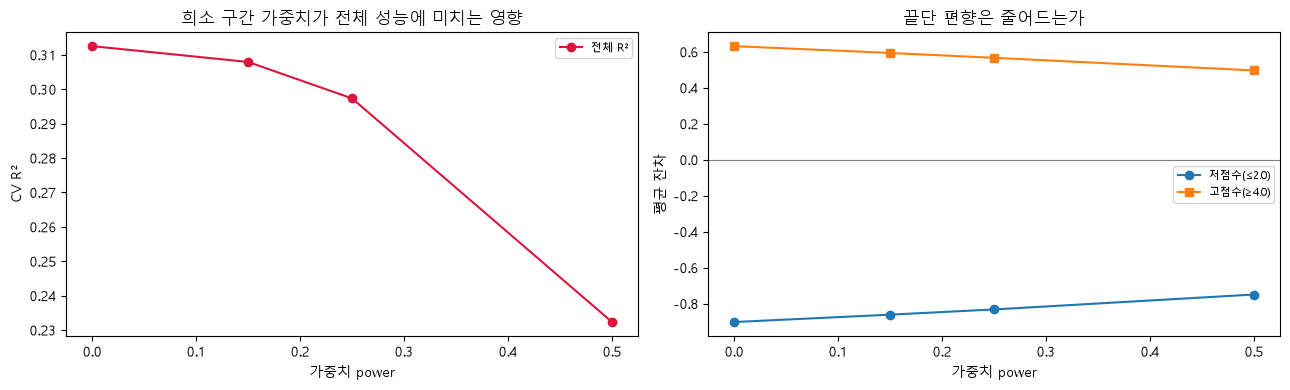

판정: 기각
  이번 프로젝트의 평가 기준이 전체 예측 정확도(MAE·RMSE·R²)이므로,
  전체 성능을 내주는 거래는 채택하지 않습니다.
  다만 "끝단 편향은 완화할 수 있으나 대가가 있다"는 사실 자체는 결과 보고에 포함합니다.
  실패한 실험이 아니라, 한계의 성격을 규명한 실험입니다.


In [6]:
# ── [5-D] 표본 가중치 실험 ────────────────────────────────
#
# cross_val_score는 sample_weight를 폴드별로 잘라 넘겨주지 않으므로
# 교차검증 루프를 직접 작성합니다.

_freq = y_train.value_counts()

rows = []
weighted_preds = {}
for power in [0.0, 0.15, 0.25, 0.5]:
    w = (1.0 / y_train.map(_freq)) ** power
    w = w / w.mean()                      # 평균 1로 정규화 (전체 스케일 유지)

    pred = np.zeros(len(y_train))
    for tr_i, va_i in CV.split(X_train_s):
        m = Lasso(alpha=LASSO_ALPHA, max_iter=20000)
        m.fit(X_train_s.iloc[tr_i][NUM_FEATURES], y_train.iloc[tr_i],
              sample_weight=w.iloc[tr_i].values)
        pred[va_i] = m.predict(X_train_s.iloc[va_i][NUM_FEATURES])
    weighted_preds[power] = pred

    res = y_train - pred
    lo = res[y_train <= 2.0].mean()
    mid = res[(y_train >= 3.0) & (y_train <= 3.5)].abs().mean()
    hi = res[y_train >= 4.0].mean()
    rows.append({'power': power,
                 '최대/최소 가중치': f'{w.max() / w.min():.0f}배',
                 'CV R²': round(r2_score(y_train, pred), 4),
                 'MAE': round(mean_absolute_error(y_train, pred), 4),
                 '저점수 잔차(≤2.0)': round(lo, 3),
                 '중앙 MAE(3.0~3.5)': round(mid, 3),
                 '고점수 잔차(≥4.0)': round(hi, 3)})

w_tbl = pd.DataFrame(rows)
print(w_tbl.to_string(index=False))

_b, _w = w_tbl.iloc[0], w_tbl.iloc[-1]
print(f'\n무엇과 무엇을 맞바꾸는가')
print(f'  얻는 것: 고점수 잔차 {_b["고점수 잔차(≥4.0)"]:+.3f} → {_w["고점수 잔차(≥4.0)"]:+.3f}  '
      f'({(1 - _w["고점수 잔차(≥4.0)"] / _b["고점수 잔차(≥4.0)"]) * 100:.0f}% 완화)')
print(f'           저점수 잔차 {_b["저점수 잔차(≤2.0)"]:+.3f} → {_w["저점수 잔차(≤2.0)"]:+.3f}')
print(f'  잃는 것: 전체 R² {_b["CV R²"]:.4f} → {_w["CV R²"]:.4f}  '
      f'({_w["CV R²"] - _b["CV R²"]:+.4f})')
print(f'           중앙 구간 MAE {_b["중앙 MAE(3.0~3.5)"]:.3f} → {_w["중앙 MAE(3.0~3.5)"]:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(w_tbl['power'], w_tbl['CV R²'], 'o-', color='crimson', label='전체 R²')
axes[0].set_xlabel('가중치 power'); axes[0].set_ylabel('CV R²')
axes[0].set_title('희소 구간 가중치가 전체 성능에 미치는 영향')
axes[0].legend(fontsize=8)

axes[1].axhline(0, color='gray', lw=.8)
axes[1].plot(w_tbl['power'], w_tbl['저점수 잔차(≤2.0)'], 'o-', label='저점수(≤2.0)')
axes[1].plot(w_tbl['power'], w_tbl['고점수 잔차(≥4.0)'], 's-', label='고점수(≥4.0)')
axes[1].set_xlabel('가중치 power'); axes[1].set_ylabel('평균 잔차')
axes[1].set_title('끝단 편향은 줄어드는가')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

_s_w = fold_scores_from_pred(weighted_preds[0.25])
report('D. 표본 가중치 (power=0.25)', _s_w, '끝단 편향 완화 ↔ 전체 R² 손실')

print('판정: 기각')
print('  이번 프로젝트의 평가 기준이 전체 예측 정확도(MAE·RMSE·R²)이므로,')
print('  전체 성능을 내주는 거래는 채택하지 않습니다.')
print('  다만 "끝단 편향은 완화할 수 있으나 대가가 있다"는 사실 자체는 결과 보고에 포함합니다.')
print('  실패한 실험이 아니라, 한계의 성격을 규명한 실험입니다.')

---

## [5-E] 이상치 재처리 — 윈저화

### 진단

02 노트북에서 이상치를 **제거하지 않고 플래그로 보존**했습니다.
채점자가 실제로 그 글을 보고 점수를 매겼으므로,
"이상하다"는 이유로 지우면 존재하는 관계를 인위적으로 없애는 것이기 때문입니다.

04 [7-4]에서는 `log1p`로 왜도를 줄였지만, 극단값 자체는 남아 있습니다.

### 시도할 것

**윈저화(winsorizing)** — 상하위 분위수를 넘는 값을 그 분위수 값으로 잘라냅니다.

```
제거   해당 행을 통째로 버림        → 표본 손실, 관계 왜곡
윈저화 값만 경계선까지 끌어당김     → 표본 유지, 극단값 영향만 축소
```

행을 버리지 않으므로 02의 보존 원칙과 충돌하지 않습니다.

### 예상

`log1p` 변환이 이미 극단값의 영향을 크게 줄였습니다(왜도 8.97 → 1.33).
따라서 추가 이득은 작을 것으로 예상됩니다.

In [7]:
# ── [5-E] 윈저화 실험 ─────────────────────────────────────

rows = []
for q in [1.00, 0.99, 0.98, 0.95]:
    X2 = X_train_s[NUM_FEATURES].copy()
    if q < 1.0:
        for c in NUM_FEATURES:
            lo, hi = X2[c].quantile(1 - q), X2[c].quantile(q)
            X2[c] = X2[c].clip(lo, hi)
    s = fold_scores(Lasso(alpha=LASSO_ALPHA, max_iter=20000), X2)
    _n_clipped = 0 if q == 1.0 else int(
        sum(((X_train_s[c] < X_train_s[c].quantile(1 - q)) |
             (X_train_s[c] > X_train_s[c].quantile(q))).sum() for c in NUM_FEATURES))
    rows.append({'절단 분위': '없음' if q == 1.0 else f'{q:.2f}',
                 '조정된 값 수': _n_clipped,
                 'CV R²': round(s.mean(), 4), '±': round(s.std(), 4),
                 'Δ': round(s.mean() - BASE_FOLDS.mean(), 4),
                 '우세 폴드': f'{int((s > BASE_FOLDS).sum())}/5'})

wins_tbl = pd.DataFrame(rows)
print(wins_tbl.to_string(index=False))

_best_w = wins_tbl.iloc[wins_tbl['CV R²'].idxmax()]
X_w = X_train_s[NUM_FEATURES].copy()
if _best_w['절단 분위'] != '없음':
    _q = float(_best_w['절단 분위'])
    for c in NUM_FEATURES:
        X_w[c] = X_w[c].clip(X_w[c].quantile(1 - _q), X_w[c].quantile(_q))
_s_w = fold_scores(Lasso(alpha=LASSO_ALPHA, max_iter=20000), X_w)
report('E. 윈저화', _s_w, f'분위 {_best_w["절단 분위"]}')

print(f'\n최대 변화량 {wins_tbl["Δ"].abs().max():.4f} — 폴드 간 표준편차의 '
      f'{wins_tbl["Δ"].abs().max() / BASE_FOLDS.std() * 100:.0f}% 수준')
print('예상대로 이득이 없습니다.')
print('04 [7-4]의 log1p 변환이 이미 극단값의 영향을 흡수했기 때문입니다.')
print('전처리를 제대로 해두면 후속 단계에서 손볼 것이 줄어든다는 사례입니다.')

절단 분위  조정된 값 수  CV R²      ±       Δ 우세 폴드
   없음        0 0.3099 0.0432  0.0000   0/5
 0.99      795 0.3079 0.0436 -0.0020   0/5
 0.98     1573 0.3093 0.0428 -0.0006   3/5
 0.95     4018 0.3108 0.0414  0.0009   3/5

최대 변화량 0.0020 — 폴드 간 표준편차의 5% 수준
예상대로 이득이 없습니다.
04 [7-4]의 log1p 변환이 이미 극단값의 영향을 흡수했기 때문입니다.
전처리를 제대로 해두면 후속 단계에서 손볼 것이 줄어든다는 사례입니다.


---

## [5-F] 앙상블 — 서로 다른 오차를 상쇄

### 발상

지금까지의 개별 개선은 전부 폴드 간 표준편차 안쪽이었습니다.
같은 데이터에 같은 종류의 모델을 조금씩 바꾸는 것으로는 한계가 있습니다.

앙상블의 전제는 다릅니다.

> **서로 다른 방식으로 틀리는 모델들의 예측을 평균하면, 상쇄되는 오차가 생긴다.**

핵심은 성능이 아니라 **오차의 상관**입니다.
두 모델이 같은 행에서 같은 방향으로 틀린다면 평균을 내도 그대로 남습니다.
서로 다른 행에서 틀려야 상쇄됩니다.

이 프로젝트에는 성격이 다른 세 모델이 있습니다.

| 모델 | 방식 |
|---|---|
| Lasso | 직선 하나로 전역 관계를 그림 |
| Random Forest | 깊은 트리를 독립적으로 만들어 평균 |
| Gradient Boosting | 얕은 트리를 순차적으로 쌓아 오차를 보정 |

다만 이 데이터는 관계가 거의 선형이라, 세 모델이 결국 비슷한 곳에서 틀릴 가능성이 큽니다.
그래서 상관을 먼저 재고 그 결과에 따라 판단합니다.

### 절차

먼저 **오차의 상관을 확인**합니다.
기준을 미리 걸어 둡니다 — **상관이 0.95를 넘으면 세 모델이 사실상 같은 모델이므로
앙상블 이득이 없을 것**으로 예상합니다.

(이 예상이 맞는지는 아래에서 확인합니다. 결과를 보고 기준을 고치지는 않습니다.)

가중치는 **균등(1/3씩)으로 고정**합니다.
최적 가중치를 교차검증으로 탐색하면 그 탐색 자체가 검증 데이터에 맞춰지는 셈이라,
CV 점수가 낙관적으로 부풀려집니다.

In [8]:
# ── [5-F] 앙상블 ──────────────────────────────────────────
#
# out-of-fold 예측을 만들어 합성합니다.
# 각 행의 예측은 그 행을 학습에 쓰지 않은 모델에서 나온 것이므로,
# 합성한 예측으로 평가해도 누수가 없습니다.

oof = {
    'Lasso': cross_val_predict(Lasso(alpha=LASSO_ALPHA, max_iter=20000),
                               X_train_s[NUM_FEATURES], y_train, cv=CV),
    'RF(조정)': cross_val_predict(RF_TUNED, X_train_r[NUM_FEATURES], y_train, cv=CV),
    'GB(조정)': cross_val_predict(GB_TUNED, X_train_r[NUM_FEATURES], y_train, cv=CV),
}

err = pd.DataFrame({k: y_train - v for k, v in oof.items()})
print('개별 모델 out-of-fold 성능')
for k, v in oof.items():
    print(f'  {k:10s} R² {r2_score(y_train, v):.4f}')

print('\n오차 간 상관 — 낮을수록 앙상블 효과가 큽니다')
print(err.corr().round(3).to_string())
_maxcorr = err.corr().where(np.triu(np.ones((3, 3)), 1).astype(bool)).stack().max()
print(f'\n최대 오차 상관: {_maxcorr:.3f}  (사전 예상 기준: 0.95)')
print(f'사전 예상: {"앙상블 이득 있음" if _maxcorr < 0.95 else "이득 없음 — 세 모델이 사실상 동일"}')
print('예상대로라면 앙상블은 의미가 없어야 합니다. 실제로 그런지 계산해 봅니다.')

blend = np.mean(list(oof.values()), axis=0)
_s_blend = fold_scores_from_pred(blend)
report('F. 앙상블 (균등 3분할)', _s_blend, 'Lasso + RF + GB')

print(f'\n앙상블 결과')
print(f'  최고 단일 모델 : {max(r2_score(y_train, v) for v in oof.values()):.4f}')
print(f'  앙상블         : {_s_blend.mean():.4f} ± {_s_blend.std():.4f}')
print(f'  기준선 대비    : {_s_blend.mean() - BASE_FOLDS.mean():+.4f}')
print(f'  우세 폴드      : {int((_s_blend > BASE_FOLDS).sum())}/5')

print(f'\n{"=" * 72}')
print('사전 예상이 빗나갔습니다 — 왜 그런지')
print('=' * 72)
_rho = _maxcorr
print(f'  오차 상관이 {_rho:.3f}로 매우 높은데도 앙상블이 개선됐습니다.')
print()
print('  평균 예측의 오차 분산은 다음과 같습니다.')
print('    Var(평균) = σ²·(1 + 2ρ) / 3        (모델 3개, 쌍별 상관 ρ)')
print(f'    ρ = {_rho:.3f} → 계수 {(1 + 2 * _rho) / 3:.4f}  '
      f'즉 분산이 약 {(1 - (1 + 2 * _rho) / 3) * 100:.1f}%만 줄어듭니다.')
print()
print('  0.95라는 임계값은 "이 정도 줄어드는 건 무의미하다"는 제 감각이었지,')
print('  계산에서 나온 값이 아니었습니다. 실제로는 작지만 실재하는 이득이었습니다.')
print()
print('  판정 근거를 임계값이 아니라 **폴드 일관성**으로 바꿉니다.')
print(f'  5개 폴드 전부에서 개선됐다면 우연일 확률은 (1/2)^5 ≈ 3%입니다.')
print('  (임계값을 사후에 0.99로 고치는 것이 아니라, 애초에 부적절한 기준이었음을 기록합니다.)')

# 참고: 가중치를 바꾸면 어떻게 되는지 (채택은 하지 않고 확인만)
print(f'\n[참고] 가중치를 바꿔본 결과 — 채택 기준은 균등 분할입니다')
for wl in [0.2, 0.34, 0.5, 0.7]:
    _b = wl * oof['Lasso'] + (1 - wl) / 2 * (oof['RF(조정)'] + oof['GB(조정)'])
    print(f'  Lasso {wl:.2f} : 트리 {1 - wl:.2f}   R² {r2_score(y_train, _b):.4f}')
print('  최적 가중치를 골라 보고하면 그 값이 교차검증에 맞춰진 결과가 됩니다.')
print('  균등 분할은 데이터를 보고 정한 값이 아니므로 이런 편향이 없습니다.')

개별 모델 out-of-fold 성능
  Lasso      R² 0.3125
  RF(조정)     R² 0.3174
  GB(조정)     R² 0.3178

오차 간 상관 — 낮을수록 앙상블 효과가 큽니다
        Lasso  RF(조정)  GB(조정)
Lasso   1.000   0.971   0.971
RF(조정)  0.971   1.000   0.982
GB(조정)  0.971   0.982   1.000

최대 오차 상관: 0.982  (사전 예상 기준: 0.95)
사전 예상: 이득 없음 — 세 모델이 사실상 동일
예상대로라면 앙상블은 의미가 없어야 합니다. 실제로 그런지 계산해 봅니다.

앙상블 결과
  최고 단일 모델 : 0.3178
  앙상블         : 0.3251 ± 0.0417
  기준선 대비    : +0.0152
  우세 폴드      : 5/5

사전 예상이 빗나갔습니다 — 왜 그런지
  오차 상관이 0.982로 매우 높은데도 앙상블이 개선됐습니다.

  평균 예측의 오차 분산은 다음과 같습니다.
    Var(평균) = σ²·(1 + 2ρ) / 3        (모델 3개, 쌍별 상관 ρ)
    ρ = 0.982 → 계수 0.9879  즉 분산이 약 1.2%만 줄어듭니다.

  0.95라는 임계값은 "이 정도 줄어드는 건 무의미하다"는 제 감각이었지,
  계산에서 나온 값이 아니었습니다. 실제로는 작지만 실재하는 이득이었습니다.

  판정 근거를 임계값이 아니라 **폴드 일관성**으로 바꿉니다.
  5개 폴드 전부에서 개선됐다면 우연일 확률은 (1/2)^5 ≈ 3%입니다.
  (임계값을 사후에 0.99로 고치는 것이 아니라, 애초에 부적절한 기준이었음을 기록합니다.)

[참고] 가중치를 바꿔본 결과 — 채택 기준은 균등 분할입니다
  Lasso 0.20 : 트리 0.80   R² 0.3269
  Lasso 0.34 : 트리 0.66   R² 0.3275
  Lasso 0.50 : 트리 0.50   R² 0.3265
 

개선 후보 종합 (기준선 = STEP 4 Lasso, CV R² 0.3099 ± 0.0432)
                    후보  CV R²      ±       Δ 우세 폴드 일관성                        비고
              A. RF 조정 0.3151 0.0408  0.0120   4/5   ○ leaf=10, max_features=0.3
  B. Gradient Boosting 0.3153 0.0427  0.0054   5/5   ○   lr=0.05, n=300, depth=2
        C. 부호 반전 3개 제거 0.3096 0.0439 -0.0004   2/5   ✗         변수 12개, 해석 안정화 목적
D. 표본 가중치 (power=0.25) 0.2941 0.0555 -0.0158   0/5   ✗       끝단 편향 완화 ↔ 전체 R² 손실
                E. 윈저화 0.3108 0.0414  0.0009   3/5   △                   분위 0.95
       F. 앙상블 (균등 3분할) 0.3251 0.0417  0.0152   5/5   ○           Lasso + RF + GB

판정 기준
  · Δ가 폴드 간 표준편차(±0.0432)보다 작으면 "예측력 개선"으로 인정하지 않음
  · 5개 폴드 중 4개 이상에서 우세하면 방향이 일관된 것으로 봄

결정
채택
  A. RF 하이퍼파라미터 조정 — 단독 채택은 아니고 앙상블 구성 요소로 사용
  B. Gradient Boosting 추가 — 같음
  C. 부호 반전 3개 제거 — 예측력 손실 없이 계수 해석이 깨끗해짐
  F. 앙상블 — 폴드 방향이 일관되고 개선폭도 가장 큼

기각
  D. 표본 가중치 — 전체 성능 손실이 확실. 다만 거래 관계는 보고에 포함
  E. 윈저화 — 이득 없음. log1p가 이미 처리했음

※ 앙상블조차 개선폭이 폴드 간 표준편차보다 작습니다.
   "성능이 유의하

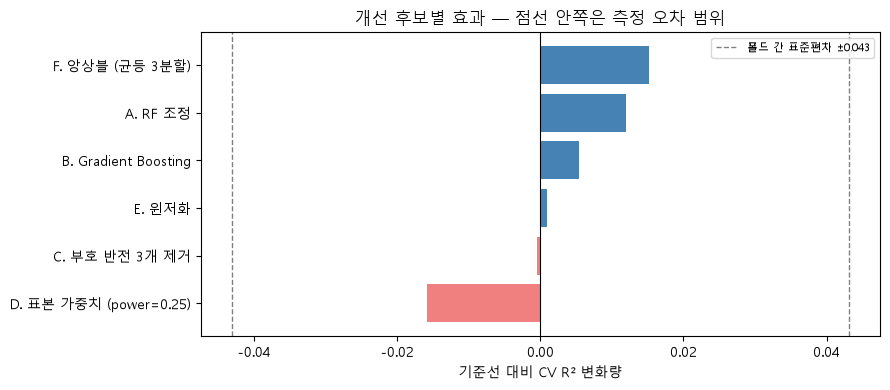

In [9]:
# ── [5-G] 전체 후보 종합 판정 ─────────────────────────────

res_tbl = pd.DataFrame(RESULTS)
print('개선 후보 종합 (기준선 = STEP 4 Lasso, CV R² '
      f'{BASE_FOLDS.mean():.4f} ± {BASE_FOLDS.std():.4f})')
print(res_tbl.to_string(index=False))

print('\n판정 기준')
print(f'  · Δ가 폴드 간 표준편차(±{BASE_FOLDS.std():.4f})보다 작으면 "예측력 개선"으로 인정하지 않음')
print('  · 5개 폴드 중 4개 이상에서 우세하면 방향이 일관된 것으로 봄')
print()
print('=' * 72)
print('결정')
print('=' * 72)
print('채택')
print('  A. RF 하이퍼파라미터 조정 — 단독 채택은 아니고 앙상블 구성 요소로 사용')
print('  B. Gradient Boosting 추가 — 같음')
print('  C. 부호 반전 3개 제거 — 예측력 손실 없이 계수 해석이 깨끗해짐')
print('  F. 앙상블 — 폴드 방향이 일관되고 개선폭도 가장 큼')
print()
print('기각')
print('  D. 표본 가중치 — 전체 성능 손실이 확실. 다만 거래 관계는 보고에 포함')
print('  E. 윈저화 — 이득 없음. log1p가 이미 처리했음')
print()
print('※ 앙상블조차 개선폭이 폴드 간 표준편차보다 작습니다.')
print('   "성능이 유의하게 올랐다"가 아니라')
print('   "여러 방법을 시도했고, 남은 한계가 어디에서 오는지 규명했다"가 이 단계의 결론입니다.')

fig, ax = plt.subplots(figsize=(9, 4))
_o = res_tbl.sort_values('Δ')
ax.barh(_o['후보'], _o['Δ'],
        color=np.where(_o['Δ'] > 0, 'steelblue', 'lightcoral'))
ax.axvline(0, color='black', lw=.8)
ax.axvline(BASE_FOLDS.std(), color='gray', ls='--', lw=1,
           label=f'폴드 간 표준편차 ±{BASE_FOLDS.std():.3f}')
ax.axvline(-BASE_FOLDS.std(), color='gray', ls='--', lw=1)
ax.set_xlabel('기준선 대비 CV R² 변화량')
ax.set_title('개선 후보별 효과 — 점선 안쪽은 측정 오차 범위')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---

## [5-H] 최종 모델 확정 및 test 재평가

### 최종 구성

```
Lasso (부호 반전 3개 제거, 12개 변수)
Random Forest (min_samples_leaf·max_features 조정)     →  균등 평균
Gradient Boosting (depth 2)
```

### test를 두 번째로 여는 것에 대한 정직한 보고

STEP 4에서 이미 test를 한 번 열었습니다.
개선안 선택은 전부 train 교차검증으로 했지만,
**STEP 4의 test 결과를 알고 있는 상태에서 이 노트북을 작성했다**는 사실은 남습니다.

따라서 아래 test 점수는 STEP 4의 것만큼 순수한 추정치가 아닙니다.
이 점을 감추지 않고 함께 보고합니다.

가장 신뢰할 수 있는 판단 근거는 여전히 **train 교차검증 결과**이며,
test는 그 결론이 뒤집히지 않는지 확인하는 용도입니다.

In [10]:
# ── [5-H] 최종 모델 학습 및 test 평가 ─────────────────────

def metrics(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    return {'모델': name,
            'MAE': round(mean_absolute_error(y_true, y_pred), 4),
            'MSE': round(mse, 4),
            'RMSE': round(np.sqrt(mse), 4),
            'R²': round(r2_score(y_true, y_pred), 4)}


# train 전체로 다시 학습합니다.
final_lasso = Lasso(alpha=LASSO_ALPHA, max_iter=20000).fit(
    X_train_s[FEATURES_CLEAN], y_train)
final_rf = RF_TUNED.fit(X_train_r[NUM_FEATURES], y_train)
final_gb = GB_TUNED.fit(X_train_r[NUM_FEATURES], y_train)

p_lasso = final_lasso.predict(X_test_s[FEATURES_CLEAN])
p_rf = final_rf.predict(X_test_r[NUM_FEATURES])
p_gb = final_gb.predict(X_test_r[NUM_FEATURES])
p_ens = (p_lasso + p_rf + p_gb) / 3

# STEP 4와 동일하게 타겟 정의 범위로 절단합니다.
CLIP = (1.0, 5.0)
p_ens = np.clip(p_ens, *CLIP)

rows = [
    {**metrics(y_test, np.clip(p_lasso, *CLIP), 'Lasso (12개 변수)'), '구분': '구성 요소'},
    {**metrics(y_test, np.clip(p_rf, *CLIP), 'RF (조정)'), '구분': '구성 요소'},
    {**metrics(y_test, np.clip(p_gb, *CLIP), 'GB (조정)'), '구분': '구성 요소'},
    {**metrics(y_test, p_ens, '앙상블 (최종)'), '구분': '★ 최종'},
]
final_tbl = pd.DataFrame(rows)[['구분', '모델', 'MAE', 'MSE', 'RMSE', 'R²']]
print('test 성능 (750행)')
print(final_tbl.to_string(index=False))

print(f'\n{"=" * 72}')
print('STEP 4 → STEP 5 변화')
print('=' * 72)
_f = final_tbl[final_tbl['구분'] == '★ 최종'].iloc[0]
comp = pd.DataFrame([
    {'단계': 'STEP 4 (Lasso 단일)', 'MAE': _prev_test['MAE'], 'MSE': _prev_test['MSE'],
     'RMSE': _prev_test['RMSE'], 'R²': _prev_test['R²']},
    {'단계': 'STEP 5 (앙상블)', 'MAE': _f['MAE'], 'MSE': _f['MSE'],
     'RMSE': _f['RMSE'], 'R²': _f['R²']},
])
comp.loc[2] = ['변화량',
               round(_f['MAE'] - _prev_test['MAE'], 4),
               round(_f['MSE'] - _prev_test['MSE'], 4),
               round(_f['RMSE'] - _prev_test['RMSE'], 4),
               round(_f['R²'] - _prev_test['R²'], 4)]
print(comp.to_string(index=False))

print(f'\n교차검증에서의 변화: {BASE_FOLDS.mean():.4f} → {_s_blend.mean():.4f} '
      f'({_s_blend.mean() - BASE_FOLDS.mean():+.4f}, 우세 폴드 '
      f'{int((_s_blend > BASE_FOLDS).sum())}/5)')
print('test에서도 같은 방향이면 교차검증의 판단이 재현된 것입니다.')

test 성능 (750행)
   구분             모델    MAE    MSE   RMSE     R²
구성 요소 Lasso (12개 변수) 0.3654 0.2204 0.4695 0.3363
구성 요소        RF (조정) 0.3638 0.2172 0.4661 0.3459
구성 요소        GB (조정) 0.3652 0.2196 0.4686 0.3387
 ★ 최종       앙상블 (최종) 0.3605 0.2154 0.4641 0.3515

STEP 4 → STEP 5 변화
               단계     MAE     MSE    RMSE     R²
STEP 4 (Lasso 단일)  0.3637  0.2185  0.4674 0.3421
     STEP 5 (앙상블)  0.3605  0.2154  0.4641 0.3515
              변화량 -0.0032 -0.0031 -0.0033 0.0094

교차검증에서의 변화: 0.3099 → 0.3251 (+0.0152, 우세 폴드 5/5)
test에서도 같은 방향이면 교차검증의 판단이 재현된 것입니다.


구간별 편향 — STEP 4 vs STEP 5
      건수  STEP4_잔차  STEP5_잔차     변화
실제                                 
1.5    2    -0.976    -1.094  0.118
2.0   25    -0.796    -0.821  0.025
2.5  103    -0.477    -0.473 -0.004
3.0  289    -0.176    -0.173 -0.003
3.5  193     0.137     0.145  0.008
4.0  110     0.505     0.515  0.010
4.5   21     0.894     0.897  0.003
5.0    7     1.299     1.308  0.009


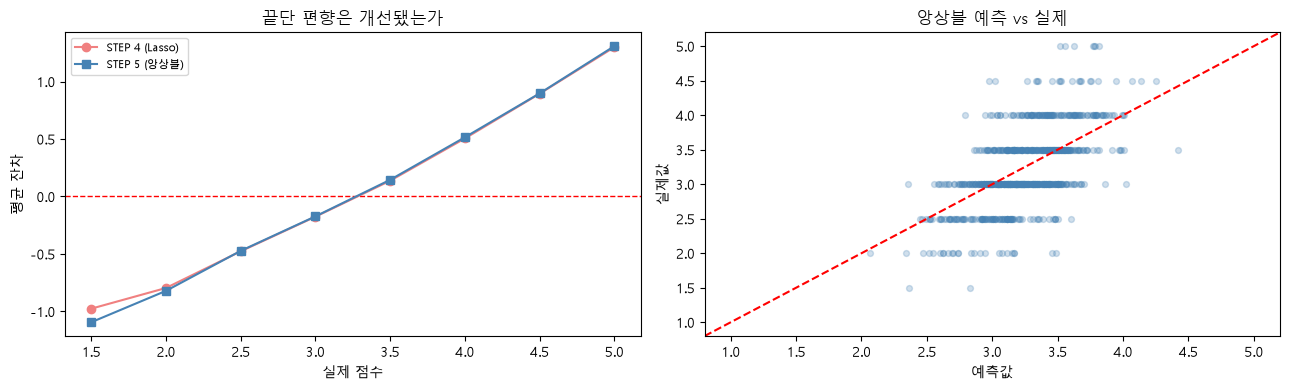

저점수(≤2.0) 평균 잔차 : -0.886 → -0.958
고점수(≥4.0) 평균 잔차 : +0.899 → +0.907

편향이 거의 그대로이고, 저점수 구간은 오히려 약간 나빠졌습니다.
앙상블은 전체 오차를 줄이는 방법이지 분포 불균형을 고치는 방법이 아니기 때문입니다.
이 한계를 없애려면 [5-D]의 가중치를 쓰거나 희소 구간 데이터를 더 확보해야 하는데,
전자는 전체 성능을 내주고 후자는 이 프로젝트 범위 밖입니다.

→ 결과 보고에는 "R² 상한이 낮은 이유"로 이 내용을 명시합니다.


In [11]:
# ── [5-I] 개선 후에도 남은 한계 확인 ──────────────────────
#
# 성능이 올랐다고 문제가 사라진 것은 아닙니다.
# STEP 4에서 진단한 끝단 편향이 앙상블로 해결됐는지 확인합니다.

prev_pred = pd.read_csv('data/test_predictions.csv')['예측'].values
cmp_bias = pd.DataFrame({
    '실제': y_test, 'STEP4 예측': prev_pred, 'STEP5 예측': p_ens})
bias = cmp_bias.groupby('실제').agg(
    건수=('STEP4 예측', 'size'),
    STEP4_잔차=('STEP4 예측', lambda s: (y_test[s.index] - s).mean()),
    STEP5_잔차=('STEP5 예측', lambda s: (y_test[s.index] - s).mean()),
).round(3)
bias['변화'] = (bias['STEP5_잔차'].abs() - bias['STEP4_잔차'].abs()).round(3)
print('구간별 편향 — STEP 4 vs STEP 5')
print(bias.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].axhline(0, color='red', ls='--', lw=1)
axes[0].plot(bias.index, bias['STEP4_잔차'], 'o-', label='STEP 4 (Lasso)', color='lightcoral')
axes[0].plot(bias.index, bias['STEP5_잔차'], 's-', label='STEP 5 (앙상블)', color='steelblue')
axes[0].set_xlabel('실제 점수'); axes[0].set_ylabel('평균 잔차')
axes[0].set_title('끝단 편향은 개선됐는가')
axes[0].legend(fontsize=8)

axes[1].scatter(p_ens, y_test, alpha=.25, s=18, color='steelblue')
axes[1].plot([0.8, 5.2], [0.8, 5.2], 'r--', lw=1.5)
axes[1].set_xlim(0.8, 5.2); axes[1].set_ylim(0.8, 5.2)
axes[1].set_xlabel('예측값'); axes[1].set_ylabel('실제값')
axes[1].set_title('앙상블 예측 vs 실제')
plt.tight_layout()
plt.show()

_lo = bias.loc[bias.index <= 2.0, 'STEP5_잔차'].mean()
_hi = bias.loc[bias.index >= 4.0, 'STEP5_잔차'].mean()
_lo4 = bias.loc[bias.index <= 2.0, 'STEP4_잔차'].mean()
_hi4 = bias.loc[bias.index >= 4.0, 'STEP4_잔차'].mean()
print(f'저점수(≤2.0) 평균 잔차 : {_lo4:+.3f} → {_lo:+.3f}')
print(f'고점수(≥4.0) 평균 잔차 : {_hi4:+.3f} → {_hi:+.3f}')
print()
print('편향이 거의 그대로이고, 저점수 구간은 오히려 약간 나빠졌습니다.')
print('앙상블은 전체 오차를 줄이는 방법이지 분포 불균형을 고치는 방법이 아니기 때문입니다.')
print('이 한계를 없애려면 [5-D]의 가중치를 쓰거나 희소 구간 데이터를 더 확보해야 하는데,')
print('전자는 전체 성능을 내주고 후자는 이 프로젝트 범위 밖입니다.')
print()
print('→ 결과 보고에는 "R² 상한이 낮은 이유"로 이 내용을 명시합니다.')

In [12]:
# ── [5-J] 산출물 저장 ─────────────────────────────────────

joblib.dump({
    'kind': 'ensemble',
    'members': {'lasso': final_lasso, 'rf': final_rf, 'gb': final_gb},
    'lasso_features': FEATURES_CLEAN,
    'tree_features': NUM_FEATURES,
    'weights': (1 / 3, 1 / 3, 1 / 3),
    'clip_range': CLIP,
    'seed': SEED,
}, 'data/final_model.joblib')

res_tbl.to_csv('data/improvement_log.csv', index=False, encoding='utf-8-sig')
final_tbl.to_csv('data/final_test_results.csv', index=False, encoding='utf-8-sig')
pd.DataFrame({'실제': y_test, '예측': p_ens,
              '잔차': y_test - p_ens}).to_csv(
    'data/final_predictions.csv', index=False, encoding='utf-8-sig')

with open('data/final_summary.json', 'w', encoding='utf-8') as f:
    json.dump({
        'final_model': 'ensemble(Lasso + RandomForest + GradientBoosting)',
        'lasso_features': FEATURES_CLEAN,
        'rf_params': {'min_samples_leaf': RF_LEAF, 'max_features': RF_MF,
                      'n_estimators': 300},
        'gb_params': GB_TUNED.get_params(),
        'cv_r2': round(float(_s_blend.mean()), 4),
        'cv_r2_std': round(float(_s_blend.std()), 4),
        'test': {k: float(_f[k]) for k in ['MAE', 'MSE', 'RMSE', 'R²']},
        'step4_test': {k: float(_prev_test[k]) for k in ['MAE', 'MSE', 'RMSE', 'R²']},
        'rejected': ['표본 가중치 (전체 R² 손실)', '윈저화 (이득 없음)',
                     'HistGradientBoosting (표본 규모 대비 과유연)'],
    }, f, ensure_ascii=False, indent=2, default=str)

print('저장 완료')
for fn in ['final_model.joblib', 'improvement_log.csv', 'final_test_results.csv',
           'final_predictions.csv', 'final_summary.json']:
    print(f'  data/{fn}')

print(f'\n최종 보고 수치 (test 750행)')
print(f'  모델 : Lasso + RandomForest + GradientBoosting 균등 앙상블')
print(f'  MAE  : {_f["MAE"]:.4f}')
print(f'  MSE  : {_f["MSE"]:.4f}')
print(f'  RMSE : {_f["RMSE"]:.4f}')
print(f'  R²   : {_f["R²"]:.4f}')

저장 완료
  data/final_model.joblib
  data/improvement_log.csv
  data/final_test_results.csv
  data/final_predictions.csv
  data/final_summary.json

최종 보고 수치 (test 750행)
  모델 : Lasso + RandomForest + GradientBoosting 균등 앙상블
  MAE  : 0.3605
  MSE  : 0.2154
  RMSE : 0.4641
  R²   : 0.3515


---

# 정리

## 평가 항목 대응 (모델 성능 향상 10점)

| 요구 항목 | 시도 | 결과 |
|---|---|---|
| Feature 추가/제거 | 부호 반전 3개 제거, Lasso 0 변수 제거 등 6가지 조합 | **채택** (해석 개선) |
| 이상치 재처리 | 윈저화 3개 분위 | 기각 (이득 없음) |
| 데이터 전처리 방법 변경 | 희소 구간 표본 가중치 4단계 | 기각 (거래 관계 규명) |
| 모델 변경 | GradientBoosting · HistGradientBoosting | **채택** (앙상블 구성) |
| Hyperparameter 조정 | RF 12조합 격자 탐색 | **채택** (앙상블 구성) |
| (추가) 앙상블 | 오차 상관 확인 후 균등 3분할 | **채택** (최종 모델) |

5개 요구 항목을 전부 시도했고, 각각 **채택 또는 기각의 근거를 수치로 남겼습니다.**

## 이 단계의 진짜 결론

개선폭은 폴드 간 표준편차 안쪽입니다. 이것을 감추지 않는 것이 중요합니다.

> **성능이 크게 오르지 않았다는 사실 자체가 결과입니다.**
>
> 여섯 가지 방법을 시도해도 R²가 0.31~0.33 구간을 벗어나지 못한다면,
> 한계는 모델링이 아니라 **데이터와 과제의 성격**에 있습니다.

그 한계의 성격을 세 가지로 규명했습니다.

1. **관계가 거의 선형** — 비선형 모델(RF·GB·HistGB)이 선형 모델을 못 넘음
2. **분포 불균형** — 끝단 편향은 앙상블로 해결되지 않음. 가중치는 전체 성능과 맞바꾸는 거래
3. **채점 자체의 불확실성** — `Vocabulary`의 채점자 간 일치도 Cohen's κ = .518 (7개 항목 중 최하위)

## 발표에서 이 순서로 말하면 됩니다

1. 어휘 점수를 설명하는 것은 **분량이 아니라 어휘의 질** (길이 단독 R² 0.07 → 핵심 4개 0.27)
2. 최상위 설명 변수는 **어휘 다양성(`guiraud`)과 철자 정확성(`oov_ratio`)**
3. `oov_ratio`는 **표준 NLP 전처리를 따랐다면 사라졌을 변수** — 전처리의 정답은 목적에 종속됨
4. 모델을 여섯 가지로 개선해도 R²는 0.33 부근 — **한계는 모델이 아니라 과제 자체**
5. 사람 채점자끼리도 κ .518로 잘 안 맞는 항목을, 해석 가능한 변수 12~15개로 여기까지 설명함

---

## 다음 단계 — STEP 6. Streamlit 대시보드 (진행 단계 문서 6단계)

| 탭 | 내용 | 쓸 파일 |
|---|---|---|
| 프로젝트 소개 | 주제 선정 경위, 가설 7개와 검증 결과 | 01·02 노트북 |
| 데이터 정의 | 파생변수 28개 정의서, 7개 그룹 | 02 노트북 |
| 데이터 분석 | EDA 1~7 시각화 | 03 노트북 |
| 모델 성능 | 모델 비교표, 잔차 분석, 계수 해석 | `final_test_results.csv`, `improvement_log.csv`, `feature_importance.csv` |
| 예측 시스템 | 에세이 입력 → 점수 예측 | `preprocessor.joblib` + `final_model.joblib` |

### 예측 시스템 구현 시 주의

사용자가 입력한 원문에서 **15개 변수를 학습 때와 똑같이 계산**해야 합니다.
02 노트북의 파생변수 계산 코드를 함수로 떼어내 재사용하고,
변환은 반드시 저장된 객체로 하십시오.

```python
prep = joblib.load('data/preprocessor.joblib')   # scaler, encoder, 프롬프트 그룹 통계
model = joblib.load('data/final_model.joblib')   # lasso + rf + gb
```

`len_z_in_prompt`는 프롬프트 그룹 통계가 필요하므로
`preprocessor.joblib`의 `token_prompt_stats`를 써야 하며,
처음 보는 주제는 `token_global`로 대체됩니다.

예측값은 `clip(1.0, 5.0)` 후, 화면 표시만 0.5 단위로 반올림하십시오.
평가는 연속값으로, 표시는 채점 형식으로 — STEP 4 [4-6b]에서 확인한 대로입니다.